### Import Libraries

In [1]:
import tensorflow as tf
import numpy as np
import random
import os

# Reproducibility
seed = 2
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Optional: disable eager execution (if using graph mode code)
tf.compat.v1.disable_eager_execution()

# Session config
session_conf = tf.compat.v1.ConfigProto(
    intra_op_parallelism_threads=1,
    inter_op_parallelism_threads=1
)
sess = tf.compat.v1.Session(config=session_conf)

# Set this session as default for everything that follows
# No set_session needed — use a context manager instead
with sess.as_default():
    # your model/code here
    pass


2025-06-09 07:38:10.888493: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-09 07:38:10.898213: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749454690.907858   28189 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749454690.911162   28189 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1749454690.919290   28189 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
import warnings
warnings.filterwarnings('ignore')

from pylab import *

import pandas as pd
import pickle
import time
import sys
import json
import os

# import statsmodels
# import statsmodels.api as sm
# from statsmodels.tsa.stattools import coint, adfuller

from datetime import timedelta
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Import Datetime and the Pandas DataReader
from datetime import datetime
from pandas_datareader import data, wb

# Import scikit instruments
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn import preprocessing
from sklearn.metrics import silhouette_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler, StandardScaler


# Import keras
from keras.models import Sequential, load_model
from keras.layers import Dense, Flatten, LSTM, GRU, Dropout, TimeDistributed
from keras.optimizers import SGD, Adam
from tensorflow.keras.layers import Conv1D, MaxPooling1D 
#from keras.layers.convolutional import Conv1D
#from keras.layers.convolutional import MaxPooling1D
from keras.callbacks import EarlyStopping, ProgbarLogger

### Function to evaluate forecasting results:

In [3]:
def evaluate_forecasting(n_pairs, true_values, prediction_values):
    mse, mae, rmse, accuracy, bias = list(), list(), list(), list(), list()
    std_dev = list()
    for i in range(n_pairs):
        mse.append(mean_squared_error(true_values[i], prediction_values[i]))
        rmse.append(np.sqrt(mean_squared_error(true_values[i], prediction_values[i])))
        mae.append(mean_absolute_error(true_values[i], prediction_values[i]))
        accuracy.append(calculate_direction_accuracy(true_values[i], prediction_values[i]))
        bias.append((true_values[i] - prediction_values[i]).mean())
        std_dev.append(prediction_values[i].std())
    print('{:.2f}E-4'.format(np.mean(mse)*10000))#Average MSE: 
    print('{:.2f}E-3'.format(np.mean(rmse)*1000))#Average RMSE: 
    print('{:.2f}E-3'.format(np.mean(mae)*1000))#Average RMSE: 
    print('{:.2f}%'.format(np.mean(accuracy)))#Average Directional Accuracy: 
    #print('Bias: {:.2f}E-4'.format(np.mean(bias)*10000))
    #print('Average Standard Deviation from prediction signal ', np.mean(std_dev))
    
    return mse, mae, rmse, accuracy

### calculate_direction_accuracy

In [4]:
def calculate_direction_accuracy(true, predictions):

        bins = [-np.inf, -0.00000001, 0.00000001, np.inf]
        names = ['-1', '0', '1']
        predictions_change = predictions.diff().fillna(0)

        predicted_direction = pd.cut(predictions_change, bins, labels=names)
        true_direction = pd.cut(true.diff().fillna(0), bins, labels=names)
        #accuracy = len(predicted_direction[predicted_direction == true_direction])/len(predicted_direction) * 100

        predicted_direction_subset = predicted_direction[true_direction != '0']
        true_direction_subset = true_direction[true_direction != '0']
        accuracy = len(predicted_direction_subset[predicted_direction_subset == true_direction_subset]) / \
                   len(predicted_direction_subset) * 100

        return accuracy

### plot_loss

In [5]:
def plot_loss(history, title, epoch_stop, metric='mse'):
    """
    Function to plot loss function.
    Arguments:
    history: History object with data from training.
    title: Plot title.
    """
    plt.figure(figsize=(7,5))
    #plt.grid()
    if metric == 'mse':
        plt.plot(history['loss'], label = "Training MSE")
        plt.plot(history['val_loss'], label = "Validation MSE")
        plt.plot([epoch_stop], [history['val_loss'][epoch_stop]],'o', color='Red', markersize=7)
        plt.annotate(
            'Best Epoch: 41\nValidation MSE:{:.3f}'.format(history['val_loss'][epoch_stop]),
            xy=(epoch_stop, history['val_loss'][epoch_stop]),
            xytext=(-20, 20),
            textcoords='offset points', ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', fc='grey', alpha=0.5),
            arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))
        plt.ylim((0,1.2))
        plt.ylabel('Mean Squared Error', size=12)
    elif metric == 'mae':
        plt.plot(history['mean_absolute_error'], label = "Training MAE")
        plt.plot(history['val_mean_absolute_error'], label = "Validation MAE")
        plt.plot([epoch_stop], [history['val_mean_absolute_error'][epoch_stop]],'o', color='Red', markersize=7)
        plt.annotate(
            'Best Epoch: 41\nValidation MAE:{:.3f}'.format(history['val_mean_absolute_error'][epoch_stop]),
            xy=(epoch_stop, history['val_mean_absolute_error'][epoch_stop]),
            xytext=(-20, 20),
            textcoords='offset points', ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.5', fc='grey', alpha=0.5),
            arrowprops=dict(arrowstyle = '->', connectionstyle='arc3,rad=0'))
        plt.ylim((0,1.2))
        plt.ylabel('Mean Absolute Error', size=12)
    plt.xlabel('Epochs', size=12)
    plt.legend()
    plt.savefig('{}_history.png'.format(metric), bbox='tight')
    
def plot_predictions(summaries):
    
    n_pairs = len(summaries)
    fig, ax = plt.subplots(n_pairs, 1, figsize=(20,25))
    
    for i in range(n_pairs):
        #title('Pair: {}'.format(i))
        predictions = summaries[i]['prediction(t)']
        spread = summaries[i]['spread(t)']
        ax[i].plot(predictions, 'b')
        ax[i].plot(spread, 'r')
    return None

In [6]:
def read_models(path='models/'):
    all_models = [] # Creates an empty list
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith(".pkl"):
                with open(path+file, 'rb') as f:
                    models = pickle.load(f)
                all_models.append(models)
                
    return all_models

### path

In [7]:
current_path='/mnt/d/GitHub/WQU-Capstone/notebooks/PCA_8-5-25'
with open(f'{current_path}/PCA_selected_pairs.pickle', 'rb') as handle: 
    pairs = pickle.load(handle)
len(pairs)

15

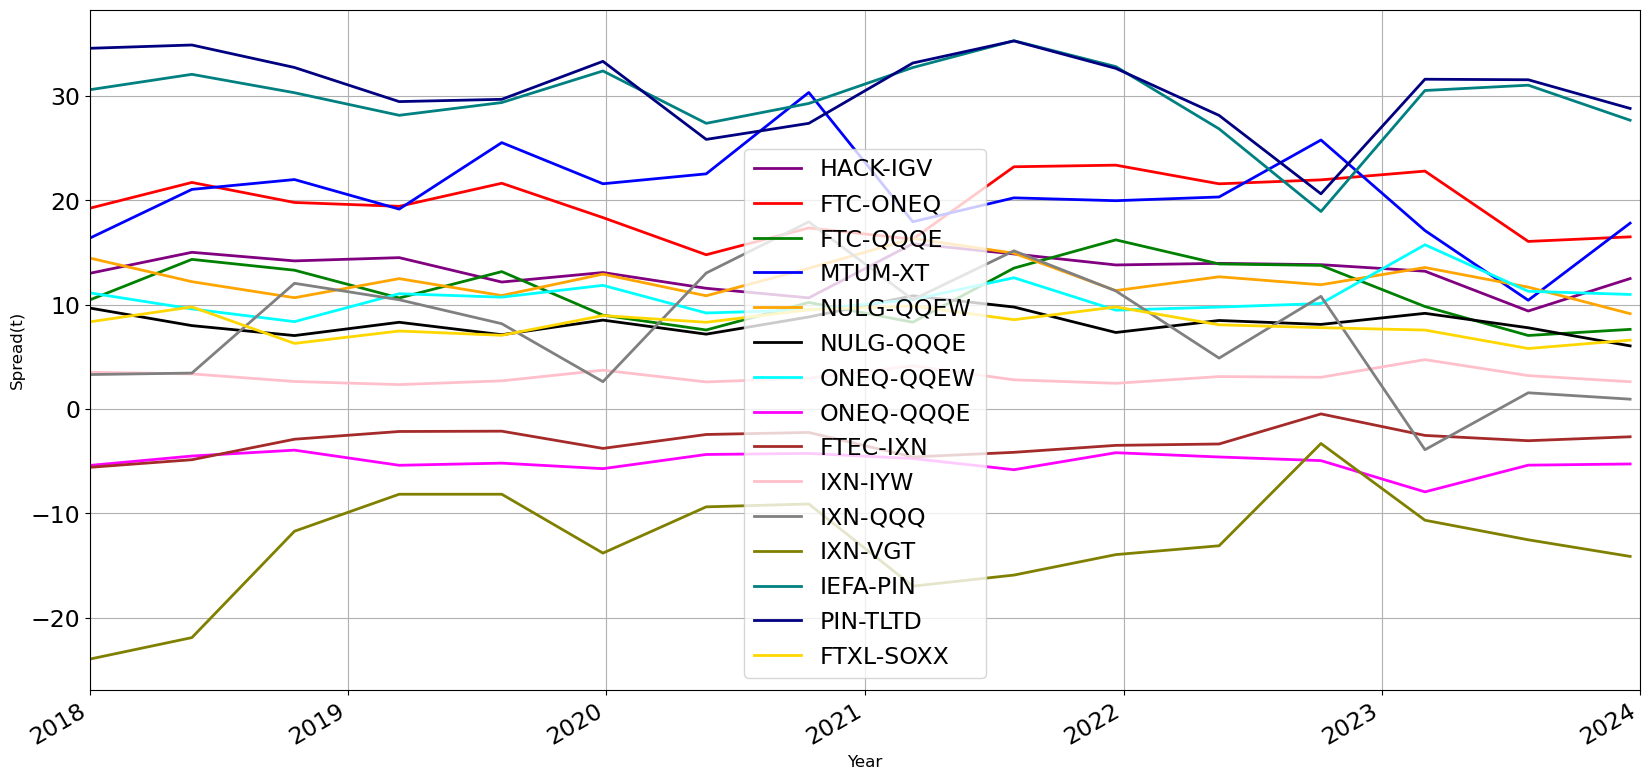

In [8]:
#markers= ["o","s","+","x","<"]
plt.rcParams.update({'font.size': 17})
colors = [
    'purple', 'red', 'green', 'blue', 'orange',
    'black', 'cyan', 'magenta', 'brown', 'pink',
    'gray', 'olive', 'teal', 'navy', 'gold'
]
for i in range(len(pairs)):
    pairs[i][2]['spread'][::100].plot(figsize=(20,10), grid=True, label='{}-{}'.format(pairs[i][0],pairs[i][1]), c=colors[i % len(colors)], linewidth=2)
plt.ylabel('Spread(t)',size=12)
plt.xlabel('Year',size=12)
plt.xlim(('2018', '2024'))
plt.legend()
#plt.savefig('spreads.png', bbox_inches='tight', pad_inches=0.05)

## Start of trading

In [9]:
ED_models = read_models(path=f'{current_path}/models/encoder_decoder/') 
ED_models

[[{'leg1': 'HACK',
   'leg2': 'IGV',
   'standardization_dict': 'scaler',
   'history': {'loss': [0.8122052550315857,
     0.6105440855026245,
     0.5024591684341431,
     0.4578469395637512,
     0.2678263783454895,
     0.21021528542041779,
     0.1643819659948349,
     0.132712721824646,
     0.10692282021045685,
     0.08976675570011139,
     0.07762885093688965,
     0.06687889993190765,
     0.06417829543352127,
     0.05673300102353096,
     0.061015188694000244,
     0.05449627712368965],
    'mae': [0.6836819648742676,
     0.5952258110046387,
     0.5076307058334351,
     0.4655103385448456,
     0.38735777139663696,
     0.3338778614997864,
     0.29587867856025696,
     0.26165056228637695,
     0.23642978072166443,
     0.21833059191703796,
     0.20366409420967102,
     0.19121092557907104,
     0.18681028485298157,
     0.1766720861196518,
     0.18010087311267853,
     0.17306461930274963],
    'val_loss': [1.2797268629074097,
     0.6516391634941101,
     0.4798868894

In [10]:
etf_list = pd.read_excel(f'{current_path}/tech_etfs.xlsx')
ticker_segment_dict = dict(zip(etf_list['Ticker'], etf_list['Description']))
ticker_segment_dict

{'ARKK': 'ARK Innovation ETF',
 'ARKQ': 'ARK Autonomous Technology & Robotics ETF',
 'ARKW': 'ARK Next Generation Internet ETF',
 'CIBR': 'First Trust NASDAQ Cybersecurity ETF',
 'CQQQ': 'Invesco China Technology ETF',
 'CWEB': 'Direxion Daily CSI China Internet Bull 2X Shares',
 'DTEC': 'ALPS Disruptive Technologies ETF',
 'FDN': 'First Trust Dow Jones Internet Index Fund',
 'FTC': 'First Trust Large Cap Growth AlphaDEX Fund',
 'FTEC': 'Fidelity MSCI Information Technology Index ETF',
 'FTXL': 'First Trust Nasdaq Semiconductor ETF',
 'FXI': 'iShares China Large-Cap ETF',
 'FXL': 'First Trust Technology AlphaDEX Fund',
 'FXP': 'ProShares UltraShort FTSE China 50',
 'FYC': 'First Trust Small Cap Growth AlphaDEX Fund',
 'GAMR': 'Wedbush ETFMG Video Game Tech ETF',
 'HACK': 'ETFMG Prime Cyber Security ETF',
 'IDLV': 'Invesco S&P International Developed Low Volatility ETF',
 'IDMO': 'Invesco S&P International Developed Momentum ETF',
 'IDX': 'VanEck Vectors Indonesia Index ETF',
 'IEFA': '

## Functions

### calculate_metrics

In [11]:
def calculate_metrics(cum_returns, n_years):
        """
        Calculate common metrics on average over all pairs.
        :param cum_returns: array with cumulative returns of every pair
        :param n_years: numbers of yers of the trading strategy
        :return: average average total roi
        :return: average annual roi
        :return: percentage of pairs with positive returns
        """
        # use below for fully invested capital:
        # cum_returns_filtered = [cum for cum in cum_returns if cum != 0]
        # or use below for commited capital:
        cum_returns_filtered = cum_returns

        avg_total_roi = np.mean(cum_returns_filtered)

        avg_annual_roi = ((1 + (avg_total_roi / 100)) ** (1 / float(n_years)) - 1) * 100
        print('Annual ROI: ', avg_annual_roi)

        cum_returns_filtered = np.asarray(cum_returns_filtered)
        positive_pct = len(cum_returns_filtered[cum_returns_filtered > 0]) * 100 / len(cum_returns_filtered)
        print('{} % of the pairs had positive returns'.format(positive_pct))

        return avg_total_roi, avg_annual_roi, positive_pct

### calculate_portfolio_sharpe_ratio

In [12]:
def calculate_portfolio_sharpe_ratio(performance, pairs):
    """
    Calculates the sharpe ratio based on the account balance of the total portfolio

    :param performance: df with summary statistics from strategy
    :param pairs: list with pairs
    """
    # calculate total daily account balance & df with returns
    total_account_balance = performance[0][1]['account_balance'].resample('D').last().dropna()
    portfolio_returns = total_account_balance.pct_change().fillna(0)
    for index in range(1, len(pairs)):
        pair_balance = performance[index][1]['account_balance'].resample('D').last().dropna()
        total_account_balance = total_account_balance + pair_balance
        portfolio_returns = pd.concat([portfolio_returns, pair_balance.pct_change().fillna(0)], axis=1)

    # add first day with initial balance
    total_account_balance = pd.concat([
        pd.Series(data=[len(pairs)],
                index=[total_account_balance.index[0] - timedelta(days=1)]),
        total_account_balance
    ])
    # total_account_balance = pd.Series(data=[len(pairs)],
    #                                   index=[total_account_balance.index[0] - timedelta(days=1)]).append(
    #                                   total_account_balance)

    # calculate portfolio volatility
    weights = np.array([1 / len(pairs)] * len(pairs))
    vol = np.sqrt(np.dot(weights.T, np.dot(portfolio_returns.cov(), weights)))

    # calculate sharpe ratio
    rf = {2014: 0.00033, 2015: 0.00053, 2016: 0.0032, 2017: 0.0093, 2018: 0.0194, 2019: 0.0206, 2020: 0.0037, 2021: 0.0004, 2022: 0.0202, 2023: 0.0507, 2024: 0.0497}
    annualized_ret = (total_account_balance[-1]-len(pairs))/len(pairs)
    year = total_account_balance.index[-1].year
    if year in rf.keys():
        # assuming iid return's distributio, sr may be calculated as:
        sharpe_ratio = (annualized_ret - rf[year]) / (vol*np.sqrt(252))
        print('Sharpe Ratio assumming IID returns: ',sharpe_ratio)
        print('Autocorrelation: ', total_account_balance.pct_change().fillna(0).autocorr(lag=1))
        # accounting for non-zero autocorrelatio, daily sr should be calculated as:
        # the daily sharpe ratio is then multiplied by the annualization factor proposed by the paper: The
        # Statistics of Sharpe Ratios by Andrew W Lo
        annualized_ret = total_account_balance.pct_change().fillna(0).mean()
        rf_daily = (1+rf[year])**(1/252)-1
        sharpe_ratio = (annualized_ret-rf_daily) /vol
        print('Daily Sharpe Ratio', sharpe_ratio)
    else:
        print('Not considering risk-free rate')
        sharpe_ratio = annualized_ret / (vol*np.sqrt(252))

    return sharpe_ratio

### calculate_maximum_drawdown

In [13]:
def calculate_maximum_drawdown(account_balance):
        """
        Function to calculate maximum drawdown w.r.t portfolio balance.

        source: https://stackoverflow.com/questions/22607324/start-end-and-duration-of-maximum-drawdown-in-python
        """

        # first calculate total drawdown period
        account_balance_drawdowns = account_balance.resample('D').last().dropna().diff().fillna(0).apply(lambda row: 0 if row >= 0 else 1)
        total_dd_duration = account_balance_drawdowns.sum()
        print('Total Drawdown Days: {} days'.format(total_dd_duration))

        xs = np.asarray(account_balance.values)

        i = np.argmax(np.maximum.accumulate(xs) - xs)  # end of the period
        if i == 0:
            plt.plot(xs)
            return 0
        else:
            j = np.argmax(xs[:i])  # start of period
            plt.figure(figsize=(10,7))
            plt.grid()
            plt.plot(xs, label='Total Account Balance')
            dates = account_balance.resample('BMS').first().dropna().index.date
            xi = np.arange(0, len(account_balance), len(account_balance)/12)
            plt.xticks(xi, dates, rotation=50)
            plt.xlim(0, len(account_balance))
            plt.plot([i, j], [xs[i], xs[j]], 'o', color='Red', markersize=10)
            plt.xlabel('Date', size=12)
            plt.ylabel('Capital($)', size=12)
            plt.legend()

        max_dd_period = round((i - j) / 78)
        print('Max DD period: {} days'.format(max_dd_period))
        print('Max DD period: {} days'.format((account_balance.index[i]-account_balance.index[j]).days))

        return (xs[i]-xs[j])/xs[j] * 100, max_dd_period, total_dd_duration

### summarize_results

In [14]:
def summarize_results(sharpe_results, cum_returns, performance, total_pairs, ticker_segment_dict, n_years):
    """
    This function summarizes interesting metrics to include in the final output
    :param sharpe_results: array containing sharpe results for each pair
    :param cum_returns: array containing cum returns for each pair
    :param performance: df containing a summary of each pair's trade
    :param total_pairs: list containing all the identified pairs
    :param ticker_segment_dict: dict containing segment for each ticker
    :param n_years: number of years the strategy is running
    :return: dictionary with metrics of interest
    """

    avg_total_roi, avg_annual_roi, positive_pct = calculate_metrics(cum_returns, n_years)#self.calculate_metrics(cum_returns, n_years)

    portfolio_sharpe_ratio = calculate_portfolio_sharpe_ratio(performance, total_pairs)#self.calculate_portfolio_sharpe_ratio(performance, total_pairs)

    sorted_indices = np.flip(np.argsort(sharpe_results), axis=0)
    # print(sorted_indices)
    # initialize list of lists
    data = []
    for index in sorted_indices:
        # get number of positive and negative positions
        position_returns = performance[index][1]['position_ret_with_costs']
        positive_positions = len(position_returns[position_returns > 0])
        negative_positions = len(position_returns[position_returns < 0])
        data.append([total_pairs[index][0],
                        ticker_segment_dict[total_pairs[index][0]],
                        total_pairs[index][1],
                        ticker_segment_dict[total_pairs[index][1]],
                        total_pairs[index][2]['t_statistic'],
                        total_pairs[index][2]['p_value'],
                        total_pairs[index][2]['zero_cross'],
                        total_pairs[index][2]['half_life'],
                        total_pairs[index][2]['hurst_exponent'],
                        positive_positions,
                        negative_positions,
                        sharpe_results[index]
                        ])

    # Create the pandas DataFrame
    pairs_df = pd.DataFrame(data, columns=['Leg1', 'Leg1_Segmt', 'Leg2', 'Leg2_Segmt', 't_statistic', 'p_value',
                                            'zero_cross', 'half_life', 'hurst_exponent', 'positive_trades',
                                            'negative_trades', 'sharpe_result'])

    pairs_df['positive_trades_per_pair_pct'] = (pairs_df['positive_trades']) / \
                                                (pairs_df['positive_trades'] + pairs_df['negative_trades']) * 100

    print('Total number of trades: ', pairs_df.positive_trades.sum() + pairs_df.negative_trades.sum())
    print('Positive trades: ', pairs_df.positive_trades.sum())
    print('Negative trades: ', pairs_df.negative_trades.sum())

    avg_positive_trades_per_pair_pct = pairs_df['positive_trades_per_pair_pct'].mean()

    results = {'n_pairs': len(sharpe_results),
                'portfolio_sharpe_ratio': portfolio_sharpe_ratio,
                'avg_total_roi': avg_total_roi,
                'avg_annual_roi': avg_annual_roi,
                'pct_positive_trades_per_pair': avg_positive_trades_per_pair_pct,
                'pct_pairs_with_positive_results': positive_pct,
                'avg_half_life': pairs_df['half_life'].mean(),
                'avg_hurst_exponent': pairs_df['hurst_exponent'].mean()}

    # Drawdown info
    total_account_balance = performance[0][1]['account_balance']
    for index in range(1, len(total_pairs)):
        total_account_balance = total_account_balance + performance[index][1]['account_balance']
    total_account_balance = total_account_balance.fillna(method='ffill')
    max_dd, max_dd_duration, total_dd_duration = calculate_maximum_drawdown(total_account_balance)#self.calculate_maximum_drawdown(total_account_balance)
    print('Maximum drawdown of portfolio: {:.2f}%'.format(max_dd))

    return results, pairs_df

### apply_costs

In [15]:
def apply_costs(row, fixed_costs_per_trade, short_costs_per_day, beta=0):
    if beta == 0:
        beta = row['beta_position']

    if row['position_during_day'] == 1. and row['trading_duration'] != 0:
        if beta >= 1:
            return fixed_costs_per_trade * (1 / beta) + fixed_costs_per_trade + short_costs_per_day * \
                    row['trading_duration']
        elif beta < 1:
            return fixed_costs_per_trade * beta + fixed_costs_per_trade + short_costs_per_day * \
                    row['trading_duration'] * beta

    elif row['position_during_day'] == -1. and row['trading_duration'] != 0:
        if beta >= 1:
            return fixed_costs_per_trade * (1 / beta) + fixed_costs_per_trade + short_costs_per_day * \
                    row['trading_duration'] * (1 / beta)
        elif beta < 1:
            return fixed_costs_per_trade * beta + fixed_costs_per_trade + short_costs_per_day * \
                    row['trading_duration']
    else:
        return 0

### add_transaction_costs

In [16]:
def add_transaction_costs(summary, beta=0, comission_costs=0.08, market_impact=0.2, short_rental=1):
    """
    Function to add transaction costs per position.
    :param summary: dataframe containing summary of all transactions
    :param beta: cointegration factor, use 0 if moving beta
    :param comission_costs: commision costs, in percentage, per security, per trade
    :param market_impact: market impact costs, in percentage, per security, per trade
    :param short_rental: short rental costs, in annual percentage
    """
    fixed_costs_per_trade = (comission_costs + market_impact) / 100  # remove percentage
    short_costs_per_day = (short_rental / 252) / 100  # remove percentage

    costs = summary.apply(lambda row: apply_costs(row, fixed_costs_per_trade, short_costs_per_day, beta),
                            axis=1)

    ret_with_costs = summary['position_return'] - costs

    return ret_with_costs

### calculate_balance

In [17]:
def calculate_balance(y, x, beta, positions, trading_durations):
    """
    Function to calculate balance during a trading session.

    :param y: y series
    :param x: x series
    :param beta: pair's cointegration coefficient
    :param positions: position during the current day
    :param trading_durations: series with trading duration of each trade
    :return: balance dataframe containing summary info
    """
    y_returns = y.pct_change().fillna(0) * positions
    x_returns = -x.pct_change().fillna(0) * positions

    leg_y = [np.nan] * len(y)  # initial balance
    leg_x = [np.nan] * len(y)  # initial balance
    pnl_y = [np.nan] * len(y)
    pnl_x = [np.nan] * len(y)
    account_balance = [np.nan] * len(y)

    # auxiliary series to indicate beginning and end of position
    new_positions_idx = positions.diff()[positions.diff() != 0].index.values
    end_positions_idx = trading_durations[trading_durations != 0].index.values
    position_trigger = pd.Series([0] * len(y), index=y.index, name='position_trigger')
    # 2: new position
    # 1: new position which only lasts one day
    # -1: end of position that did not start on that day
    position_trigger[new_positions_idx] = 2.
    position_trigger[end_positions_idx] = position_trigger[end_positions_idx] - 1.
    position_trigger = position_trigger * positions.abs()
    position_trigger.name = 'position_trigger'

    for i in range(len(y)):
        if i == 0:
            pnl_y[0] = 0
            pnl_x[0] = 0
            account_balance[0] = 1
            if beta > 1:
                leg_y[0] = 1 / beta
                leg_x[0] = 1
            else:
                leg_y[0] = 1
                leg_x[0] = beta
        elif positions[i] == 0:
            pnl_y[i] = 0
            pnl_x[i] = 0
            leg_y[i] = leg_y[i - 1]
            leg_x[i] = leg_x[i - 1]
            account_balance[i] = account_balance[i-1]
        else:
            # add costs
            if position_trigger[i] == 1:
                # every new position invest initial 1$ + acc in X + acc in Y
                position_investment = account_balance[i-1]
                # if new position, that most legs contain now the overall invested
                if beta > 1:
                    pnl_y[i] = y_returns[i] * position_investment * (1 / beta)
                    pnl_x[i] = x_returns[i] * position_investment
                else:
                    pnl_y[i] = y_returns[i] * position_investment
                    pnl_x[i] = x_returns[i] * position_investment * beta

                # update legs
                if beta > 1:
                    if positions[i] == 1:
                        leg_y[i] = position_investment * (1 / beta) + pnl_y[i]
                        leg_x[i] = position_investment - pnl_x[i]
                    else:
                        leg_y[i] = position_investment * (1 / beta) - pnl_y[i]
                        leg_x[i] = position_investment + pnl_x[i]
                else:
                    if positions[i] == 1:
                        leg_y[i] = position_investment + pnl_y[i]
                        leg_x[i] = position_investment * beta - pnl_x[i]
                    else:
                        leg_y[i] = position_investment - pnl_y[i]
                        leg_x[i] = position_investment * beta + pnl_x[i]

                # commission costs + market impact costs + short rental costs
                if beta >= 1:
                    pnl_y[i] = pnl_y[i] - 0.0028*(1/beta)*position_investment # add commission + bid ask spread
                    pnl_x[i] = pnl_x[i] - 0.0028*position_investment # add commission + bid ask spread
                    if positions[i] == 1:
                        pnl_x[i] = pnl_x[i] - 1 * (0.01 / 252)*position_investment
                    elif positions[i] == -1:
                        pnl_y[i] = pnl_y[i] - 1 * (0.01 / 252)*(1/beta)*position_investment
                elif beta < 1:
                    pnl_y[i] = pnl_y[i] - 0.0028 * position_investment  # add commission + bid ask spread
                    pnl_x[i] = pnl_x[i] - 0.0028 * beta * position_investment  # add commission + bid ask spread
                    if positions[i] == 1:
                        pnl_x[i] = pnl_x[i] - 1 * (0.01 / 252)*beta*position_investment
                    elif positions[i] == -1:
                        pnl_y[i] = pnl_y[i] - 1 * (0.01 / 252)*position_investment
                # update balance
                account_balance[i] = account_balance[i-1] + pnl_x[i] + pnl_y[i]

            elif position_trigger[i] == 2:
                # every new position invest initial 1$ + acc in X + acc in Y
                position_investment = account_balance[i-1]
                # if new position, that most legs contain now the overall invested
                if beta > 1:
                    pnl_y[i] = y_returns[i] * position_investment * (1 / beta)
                    pnl_x[i] = x_returns[i] * position_investment
                else:
                    pnl_y[i] = y_returns[i] * position_investment
                    pnl_x[i] = x_returns[i] * position_investment * beta

                # update legs
                if beta > 1:
                    if positions[i] == 1:
                        leg_y[i] = position_investment * (1 / beta) + pnl_y[i]
                        leg_x[i] = position_investment - pnl_x[i]
                    else:
                        leg_y[i] = position_investment * (1 / beta) - pnl_y[i]
                        leg_x[i] = position_investment + pnl_x[i]
                else:
                    if positions[i] == 1:
                        leg_y[i] = position_investment + pnl_y[i]
                        leg_x[i] = position_investment * beta - pnl_x[i]
                    else:
                        leg_y[i] = position_investment - pnl_y[i]
                        leg_x[i] = position_investment * beta + pnl_x[i]

                # commission costs + market impact costs + short rental costs
                if beta >= 1:
                    pnl_y[i] = pnl_y[i] - 0.0028*(1/beta)*position_investment # add commission + bid ask spread
                    pnl_x[i] = pnl_x[i] - 0.0028*position_investment # add commission + bid ask spread
                elif beta < 1:
                    pnl_y[i] = pnl_y[i] - 0.0028 * position_investment  # add commission + bid ask spread
                    pnl_x[i] = pnl_x[i] - 0.0028 * beta * position_investment  # add commission + bid ask spread
                # update balance
                account_balance[i] = account_balance[i - 1] + pnl_x[i] + pnl_y[i]

            else:
                # calculate trade pnl
                pnl_y[i] = y_returns[i] * leg_y[i - 1]
                pnl_x[i] = x_returns[i] * leg_x[i - 1]

                # update legs
                if positions[i] == 1:
                    leg_y[i] = leg_y[i - 1] + pnl_y[i]
                    leg_x[i] = leg_x[i - 1] - pnl_x[i]
                else:
                    leg_y[i] = leg_y[i - 1] - pnl_y[i]
                    leg_x[i] = leg_x[i - 1] + pnl_x[i]

                # add short costs
                if position_trigger[i] == -1:
                    if positions[i]==1:
                        if beta > 1:
                            pnl_x[i] = pnl_x[i] - trading_durations[i] * (0.01 / 252) * position_investment
                        elif beta < 1:
                            pnl_x[i] = pnl_x[i] - trading_durations[i] * (0.01 / 252)*beta*position_investment
                    elif positions[i]==-1:
                        if beta > 1:
                            pnl_y[i] = pnl_y[i] - trading_durations[i] * (0.01 / 252)*(1/beta)*position_investment
                        elif beta < 1:
                            pnl_y[i] = pnl_y[i] - trading_durations[i] * (0.01 / 252) * position_investment

                # update balance
                account_balance[i] = account_balance[i - 1] + pnl_x[i] + pnl_y[i]
    pnl = [pnl_y[i] + pnl_x[i] for i in range(len(y))]

    # join everything in dataframe
    balance = pd.Series(data=account_balance, index=y.index, name='account_balance')
    returns = balance.pct_change().fillna(0)
    returns.name = 'returns'
    pnl = pd.Series(data=pnl, index=y.index, name='pnl')
    pnl_y = pd.Series(data=pnl_y, index=y.index, name='pnl_y')
    pnl_x = pd.Series(data=pnl_x, index=y.index, name='pnl_x')
    leg_y = pd.Series(data=leg_y, index=y.index, name='leg_y')
    leg_x = pd.Series(data=leg_x, index=y.index, name='leg_x')
    balance_summary = pd.concat(
            [balance, pnl, pnl_y, pnl_x, leg_y, leg_x, returns, position_trigger, positions, y, x,
                trading_durations], axis=1)

    return balance_summary

### return_per_position

In [18]:
def return_per_position(row, beta=None, sliding=False):
    if row['end_position'] != 0:
        y_returns = (row['y'] - row['y_entry']) / row['y_entry']
        x_returns = (row['x'] - row['x_entry']) / row['x_entry']
        if sliding:
            beta = row['beta_position']
        if beta > 1.:
            return ((1 / beta) * y_returns - 1 * x_returns) * row['positions']
        else:
            return (y_returns - beta * x_returns) * row['positions']
    else:
        return 0

### calculate_position_returns

In [19]:
def calculate_position_returns(y, x, beta, positions):
    """
    This method receives the series with the positions and calculate the return at the end of each position, not
    yet accounting for costs

    Y: price of ETF Y
    X: price of ETF X
    beta: cointegration ratio
    positions: array indicating position to enter in next day
    """
    # get copy of series
    y = y.copy()
    y.name = 'y'
    x = x.copy()
    x.name = 'x'

    # positions preceed the day when the position is actually entered!
    # get indices before entering position
    new_positions = positions.diff()[positions.diff() != 0].index.values
    # create variable for signalizing end of position
    end_position = pd.Series(data=[0] * len(y), index=y.index, name='end_position')
    end_position[new_positions] = 1.
    # add end position if trading period is over and position is open
    if positions[-1] != 0:
        end_position[-1] = 1.

    # get corresponding X and Y
    y_entry = pd.Series(data=[np.nan] * len(y), index=y.index, name='y_entry')
    x_entry = pd.Series(data=[np.nan] * len(y), index=y.index, name='x_entry')
    y_entry[new_positions] = y[new_positions]
    x_entry[new_positions] = x[new_positions]
    y_entry = y_entry.shift().fillna(method='ffill')
    x_entry = x_entry.shift().fillna(method='ffill')

    # name positions series
    positions.name = 'positions'

    # apply returns per trade
    # each row contain all the parameters to be applied in that position
    df = pd.concat([y, x, positions.shift().fillna(0), y_entry, x_entry, end_position], axis=1)
    returns = df.apply(lambda row: return_per_position(row, beta), axis=1).fillna(0)
    cum_returns = np.cumprod(returns + 1) - 1
    df['ret'] = returns
    returns.name = 'position_return'

    return returns, cum_returns, df

### add_trading_duration

In [20]:
def add_trading_duration(df):
    """
    The following function adds a column containing the trading duration in days.
    :param df: Dataframe containing column with positions to enter in next day
    """

    df['trading_duration'] = [0] * len(df)
    previous_unit = 0.
    new_position_counter = 0
    day = df.index[0].day
    for index, row in df.iterrows():
        if previous_unit == row['numUnits']:
            if previous_unit != 0.:
                # update counter
                if index.day != day:
                    new_position_counter += 1
                    day = index.day
                # verify if it is last trading day
                if index == df.index[-1]:
                    df.loc[index, 'trading_duration'] = new_position_counter
            continue  # no change in positions to verify
        else:
            if previous_unit == 0.:
                previous_unit = row['numUnits']
                # begin counter
                new_position_counter = 1
                day = index.day
                continue  # simply start the trade
            else:
                df.loc[index, 'trading_duration'] = new_position_counter
                previous_unit = row['numUnits']
                # begin counter
                new_position_counter = 1
                day = index.day
                continue

    return df['trading_duration']

### forecast_spread_trading

In [21]:
def forecast_spread_trading(X, Y, spread_test, spread_train, beta, predictions, lag,
                            low_quantile=0.15, high_quantile=0.85, multistep=0):
    """
    This function will set the trading positions based on the forecasted spread.
    For each day, the function compares the predicted spread for that day with the true value of the spread in tha day before, giving the predicted spread pct change.
    In case it is larger than the threshold, a position is entered.
    Note: because a position entered in day n, it is only accounted for on the day after, we shift the entered positions.
    : predictions: predictions should not be standardized, but with regular mean and variance.
    """
    # 1. Get predictions pct_change
    # we want to see the pct change of the prediction compared to the true value but the previous instant time, because we are interested in seeing the temporal % change
    if multistep == 0:
        predictions_1 = predictions
        predictions_2 = pd.Series(data=[0]*len(predictions), index=predictions.index)
        predictions_pct_change = (((predictions_1 - spread_test.shift(lag)) /
                                    abs(spread_test.shift(lag))) * 100).fillna(0)
        # true_change = spread_test.diff().fillna(0)
    else:
        predictions_1, predictions_2 = predictions['t'], predictions['t+1']
        predictions_pct_change = (((predictions_2 - spread_test.shift(lag)) /
                                    abs(spread_test.shift(lag))) * 100).fillna(0)
        # need to add last row and first row correspondingly
        predictions_1 = predictions_1.append(pd.Series(data=predictions_2[-1], index=spread_test[-1:].index))
        predictions_2 = pd.concat([pd.Series(data=predictions_1[0], index=predictions_1[:1].index), predictions_2])

    # 2. Calculate trading thresholds
    spread_train_pct_change = ((spread_train - spread_train.shift(lag+multistep)) /
                                abs(spread_train.shift(lag+multistep))) * 100
    positive_changes = spread_train_pct_change[spread_train_pct_change > 0]
    negative_changes = spread_train_pct_change[spread_train_pct_change < 0]
    long_threshold = positive_changes.quantile(q=high_quantile, interpolation='linear')
    #print('Long threshold: {:.2f}'.format(long_threshold))
    short_threshold = negative_changes.quantile(q=low_quantile, interpolation='linear')
    #print('Short threshold: {:.2f}'.format(short_threshold))

    # 3. Define trading timings
    # Note: If we want to enter a position at the beginning of day N,
    # because of the way pnl is calculated the position is entered
    # in the previous day.
    # Example: In day 23 the percentage change is 55% (wrt day 22). If we were to enter the
    # position in day 23, the following code would not consider the gains during day 23, even if we had
    # set the position in the morning. (it conly considers the gains for the next days)
    # Thus, as a workaoround, we enter the position at day 22 (at night), and it considers the gains for day 23
    numUnits = pd.Series(data=[0.] * len(spread_test), index=spread_test.index, name='numUnits')
    longsEntry = predictions_pct_change > long_threshold
    longsEntry = longsEntry.shift(-1).fillna(False)
    numUnits[longsEntry] = 1.
    shortsEntry = predictions_pct_change < short_threshold
    shortsEntry = shortsEntry.shift(-1).fillna(False)
    numUnits[shortsEntry] = -1

    # ffill if applicable
    if lag == 1:
        pct_change_from_previous = predictions_pct_change
    else:
        pct_change_from_previous = predictions_pct_change = (((predictions_1 - spread_test.shift(1)) /
                                                                abs(spread_test.shift(1))) * 100).fillna(0)
    for i in range(1, len(numUnits) - 1):
        if numUnits[i] != 0:
            continue
        else:
            if numUnits[i - 1] == 0:
                continue
            elif numUnits[i - 1] == 1.:
                if pct_change_from_previous[i + 1] > 0:
                    numUnits[i] = 1
                    continue
            elif numUnits[i - 1] == -1.:
                if pct_change_from_previous[i + 1] < 0:
                    numUnits[i] = -1.
                    continue

    # 4. Calculate P&L and Returns
    #trader = class_Trader.Trader()

    # concatenate for positions with not enough data to be predicted
    lookback = len(Y)-len(spread_test)
    numUnits_not_predicted = pd.Series(data=[0.] * lookback, index=Y.index[:lookback])
    numUnits = pd.concat([numUnits_not_predicted, numUnits], axis=0)
    numUnits.name = 'numUnits'
    # add trade durations
    numUnits_df = pd.DataFrame(numUnits, index=Y.index)
    numUnits_df = numUnits_df.rename(columns={"positions": "numUnits"})
    trading_durations = add_trading_duration(numUnits_df)#trader.add_trading_duration(numUnits_df)
    # calculate balance
    balance_summary = calculate_balance(Y, X, beta, numUnits.shift(1).fillna(0), trading_durations)#trader.calculate_balance(Y, X, beta, numUnits.shift(1).fillna(0), trading_durations)
    # calculate return per position
    position_ret, _, _ = calculate_position_returns(Y, X, beta, numUnits)#trader.calculate_position_returns(Y, X, beta, numUnits)
    df = pd.DataFrame({'position_return':position_ret.values,
                        'trading_duration':trading_durations,
                        'position_during_day': numUnits.shift(1).fillna(0).values},
                        index = position_ret.index)
    position_ret_with_costs = add_transaction_costs(df, beta)#trader.add_transaction_costs(df, beta)
    balance_summary['position_ret_with_costs']=position_ret_with_costs

    # summarize
    ret_with_costs, cum_ret_with_costs = balance_summary.returns, (balance_summary.account_balance-1)
    bins = [-np.inf, -0.00000001, 0.00000001, np.inf]
    names = ['-1', '0', '1']
    summary = pd.DataFrame(data={'prediction(t)': predictions_1.values,
                                    'prediction(t+1)': predictions_2.values,
                                    'spread(t)': spread_test.values,
                                    'predicted_change(%)': predictions_pct_change,
                                    'position_during_day': numUnits.shift(1).fillna(0).values[lookback:],
                                    'position_return': position_ret,
                                    'position_ret_with_costs': position_ret_with_costs,
                                    'trading_days': trading_durations[lookback:],
                                    'ret_with_costs': ret_with_costs[lookback:],
                                    'predicted_direction': pd.cut(predictions_pct_change, bins, labels=names),
                                    'true_direction': pd.cut(spread_test.diff(), bins, labels=names)
                                    },
                            index=spread_test.index)

    return ret_with_costs, cum_ret_with_costs, summary, balance_summary

### calculate_sharpe_ratio

In [22]:
def calculate_sharpe_ratio(n_years, n_days, ret):
        """
        Calculate sharpe ratio for one asset only.
        As an estimate of the expected value use the yearly return.
        :param n_years: number of years being considered
        :param n_days: number of trading days per year
        :param ret: array containing returns per timestep
        """
        rf = {2014: 0.00033, 2015: 0.00053, 2016: 0.0032, 2017: 0.0093, 2018: 0.0194, 2019: 0.0206, 2020: 0.0037, 2021: 0.0004, 2022: 0.0202, 2023: 0.0507, 2024: 0.0497}
        time_in_market = n_years * n_days
        daily_index = ret.resample('D').last().dropna().index
        daily_ret = (ret + 1).resample('D').prod() - 1
        # remove added days from resample
        daily_ret = daily_ret.loc[daily_index]

        annualized_ret = (np.cumprod(1 + ret) - 1)[-1]
        year = ret.index[0].year
        if year in rf.keys():
            sharpe_ratio = (annualized_ret-rf[year]) / (np.std(daily_ret)*np.sqrt(time_in_market))
        else:
            print('Not considering risk-free rate')
            sharpe_ratio = annualized_ret / (np.std(daily_ret)*np.sqrt(time_in_market))

        return sharpe_ratio

### run_specific_model

In [23]:
def run_specific_model(n_in, hidden_nodes, pairs, path='models/', train_val_split='2023-01-01', lag=1,
                        multistep=0, low_quantile=0.10, high_quantile=0.90):

    #nodes_name = str(hidden_nodes[0]) + '_' + str(hidden_nodes[1]) if len(hidden_nodes) > 1 else str(hidden_nodes[0])
    file_name = 'models_n_in-' + str(n_in) + '_hidden_nodes-' + str(hidden_nodes) + '.pkl'

    with open(path + file_name, 'rb') as f:
        model = pickle.load(f)

    model_cumret, model_sharpe_ratio = list(), list()
    balance_summaries, summaries = list(), list()
    for pair_i in range(len(model) - 1):
        print('\nPair loaded: {}_{}:'.format(model[pair_i]['leg1'], model[pair_i]['leg2']))
        print('Check pairs: {}_{}.'.format(pairs[pair_i][0], pairs[pair_i][1]))
        predictions = model[pair_i]['predictions_val']

        ret, cumret, summary, balance_summary = forecast_spread_trading(
                                                        X=pairs[pair_i][2]['X_train'][train_val_split:],
                                                        Y=pairs[pair_i][2]['Y_train'][train_val_split:],
                                                        spread_test=pairs[pair_i][2]['spread'][train_val_split:],
                                                        spread_train=pairs[pair_i][2]['spread'][:train_val_split],
                                                        beta=pairs[pair_i][2]['coint_coef'],
                                                        predictions=predictions,
                                                        lag=lag,
                                                        low_quantile=low_quantile,
                                                        high_quantile=high_quantile,
                                                        multistep=multistep)

        print('Accumulated return: {:.2f}%'.format(cumret[-1] * 100))

        #trader = class_Trader.Trader()
        if np.std(ret) != 0:
            sharpe_ratio = calculate_sharpe_ratio(1, 252, ret)#trader.calculate_sharpe_ratio(1, 252, ret)
        else:
            sharpe_ratio = 0
        print('Sharpe Ratio:', sharpe_ratio)

        model_cumret.append(cumret[-1] * 100)
        model_sharpe_ratio.append(sharpe_ratio)
        summaries.append(summary)
        balance_summaries.append(balance_summary)

    return model, model_cumret, model_sharpe_ratio, summaries, balance_summaries

### test_specific_model

In [24]:
def test_specific_model(n_in, hidden_nodes, pairs, path, train_test_split='2024-01-01', lag=1,
                        low_quantile=0.10, high_quantile=0.90, multistep=0, profitable_pairs_indices=None):

    #nodes_name = str(hidden_nodes[0]) + '_' + str(hidden_nodes[1]) if len(hidden_nodes) > 1 else str(hidden_nodes[0])
    file_name = 'models_n_in-' + str(n_in) + '_hidden_nodes-' + str(hidden_nodes) + '.pkl'

    with open(path + file_name, 'rb') as f:
        model = pickle.load(f)

    model_cumret, model_sharpe_ratio = list(), list()
    summaries, balance_summaries = list(), list()
    for pair_i in range(len(model) - 1):
        if pair_i in profitable_pairs_indices:
            print('\nPair loaded: {}_{}:'.format(model[pair_i]['leg1'], model[pair_i]['leg2']))
            print('Check pairs: {}_{}.'.format(pairs[pair_i][0], pairs[pair_i][1]))
            predictions = model[pair_i]['predictions_test']
            spread_test = pairs[pair_i][2]['Y_test'] - pairs[pair_i][2]['coint_coef'] * pairs[pair_i][2]['X_test']

            ret, cumret, summary, balance_summary = forecast_spread_trading(
                                                        X=pairs[pair_i][2]['X_test'],
                                                        Y=pairs[pair_i][2]['Y_test'],
                                                        spread_test=spread_test[-len(predictions)-multistep:],
                                                        spread_train=pairs[pair_i][2]['spread'][:train_test_split],
                                                        beta=pairs[pair_i][2]['coint_coef'],
                                                        predictions=predictions,
                                                        lag=lag,
                                                        low_quantile=low_quantile,
                                                        high_quantile=high_quantile,
                                                        multistep=multistep)

            print('Accumulated return: {:.2f}%'.format(cumret[-1] * 100))

            #trader = class_Trader.Trader()
            if np.std(ret) != 0:
                sharpe_ratio = calculate_sharpe_ratio(1, 252, ret)#trader.calculate_sharpe_ratio(1, 252, ret)
            else:
                sharpe_ratio = 0
            print('Sharpe Ratio:', sharpe_ratio)

            model_cumret.append(cumret[-1] * 100)
            model_sharpe_ratio.append(sharpe_ratio)
            summaries.append(summary)
            balance_summaries.append(balance_summary)

    return model, model_cumret, model_sharpe_ratio, summaries, balance_summaries

## Validation

In [25]:
# model to test
n_in = 24
hidden_nodes = [32, 16]
low_quantile = 0.10
high_quantile = 0.90
train_val_split = '01-01-2023'

current_path=(f'{current_path}/models/encoder_decoder/')

In [26]:
model_rnn, cumret_val, sharperatio_val,summaries_rnn, balance_summaries_rnn = run_specific_model(
                                                n_in, 
                                                hidden_nodes, 
                                                pairs,
                                                path=current_path,
                                                train_val_split=train_val_split,
                                                low_quantile=low_quantile, 
                                                high_quantile=high_quantile, 
                                                lag=1,
                                                )


Pair loaded: HACK_IGV:
Check pairs: HACK_IGV.
Accumulated return: 7.74%
Sharpe Ratio: 0.322466267379928

Pair loaded: FTC_ONEQ:
Check pairs: FTC_ONEQ.
Accumulated return: -2.22%
Sharpe Ratio: -0.812931972876497

Pair loaded: FTC_QQQE:
Check pairs: FTC_QQQE.
Accumulated return: -10.34%
Sharpe Ratio: -1.8045412692205272

Pair loaded: MTUM_XT:
Check pairs: MTUM_XT.
Accumulated return: -7.26%
Sharpe Ratio: -0.7935987829532062

Pair loaded: NULG_QQEW:
Check pairs: NULG_QQEW.
Accumulated return: -7.55%
Sharpe Ratio: -2.0791157611691777

Pair loaded: NULG_QQQE:
Check pairs: NULG_QQQE.
Accumulated return: -5.81%
Sharpe Ratio: -1.9633288969565956

Pair loaded: ONEQ_QQEW:
Check pairs: ONEQ_QQEW.
Accumulated return: -4.80%
Sharpe Ratio: -1.3216441946407727

Pair loaded: ONEQ_QQQE:
Check pairs: ONEQ_QQQE.
Accumulated return: -0.70%
Sharpe Ratio: -0.9081548244720665

Pair loaded: FTEC_IXN:
Check pairs: FTEC_IXN.
Accumulated return: 0.19%
Sharpe Ratio: -2.8385816700534376

Pair loaded: IXN_IYW:
Che

In [27]:
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(pairs))]
performance_rnn

[(            prediction(t)  prediction(t+1)  spread(t)  predicted_change(%)  \
  date                                                                         
  2023-01-03      13.692456                0  13.716926             0.000000   
  2023-01-04      13.674649                0  13.678756            -0.308209   
  2023-01-05      13.657242                0  13.207292            -0.157278   
  2023-01-06      13.494191                0  13.249335             2.172281   
  2023-01-09      13.401628                0  12.626092             1.149433   
  ...                   ...              ...        ...                  ...   
  2023-12-22      12.878778                0  12.651341             3.112691   
  2023-12-26      12.906421                0  12.857868             2.016226   
  2023-12-27      12.984328                0  12.778152             0.983525   
  2023-12-28      13.000592                0  12.724672             1.740786   
  2023-12-29      12.986732             

Annual ROI:  -5.033785724914786
26.666666666666668 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -3.9629802400217486
Autocorrelation:  -0.04318718123605354
Daily Sharpe Ratio -0.2495499871437378
Total number of trades:  174
Positive trades:  81
Negative trades:  93
Total Drawdown Days: 145 days
Max DD period: 2 days
Max DD period: 248 days
Maximum drawdown of portfolio: -6.30%


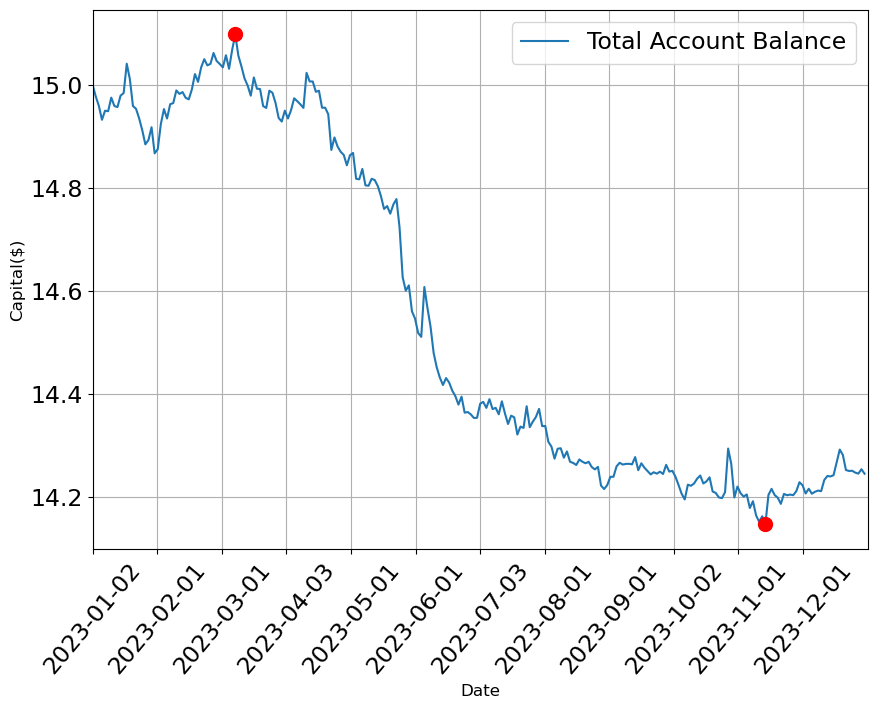

In [28]:
#print('\n')
results, pairs_summary = summarize_results(sharperatio_val,
                                                  cumret_val,
                                                  performance_rnn,
                                                  pairs, ticker_segment_dict,
                                                  n_years=1)

In [29]:
pairs_summary

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,FTXL,First Trust Nasdaq Semiconductor ETF,SOXX,iShares PHLX Semiconductor ETF,-2.867138,0.049305,97,31,0.367390,6,3,0.591692,66.666667
1,HACK,ETFMG Prime Cyber Security ETF,IGV,iShares Expanded Tech-Software Sector ETF,-3.519986,0.007488,60,59,0.397805,6,1,0.322466,85.714286
2,IXN,iShares Global Tech ETF,VGT,Vanguard Information Technology Index Fund ETF...,-3.262747,0.016628,64,50,0.407756,0,0,0.000000,NaN
3,IEFA,iShares Core MSCI EAFE ETF,PIN,Invesco India ETF,-2.703027,0.073516,73,77,0.471957,6,6,-0.426503,50.000000
4,MTUM,iShares MSCI USA Momentum Factor ETF,XT,iShares Exponential Technologies ETF,-4.375083,0.000328,114,28,0.374344,8,6,-0.793599,57.142857
5,FTC,First Trust Large Cap Growth AlphaDEX Fund,ONEQ,Fidelity Nasdaq Composite Index ETF,-2.924680,0.042552,82,60,0.451281,10,6,-0.812932,62.500000
6,ONEQ,Fidelity Nasdaq Composite Index ETF,QQQE,Direxion NASDAQ-100 Equal Weighted Index Shares,-2.966076,0.038186,104,40,0.444484,7,7,-0.908155,50.000000
7,ONEQ,Fidelity Nasdaq Composite Index ETF,QQEW,First Trust NASDAQ-100 Equal Weighted Index Fund,-3.491915,0.008197,102,38,0.437543,8,9,-1.321644,47.058824
8,PIN,Invesco India ETF,TLTD,FlexShares Morningstar Developed Markets ex-US...,-2.926240,0.042381,45,85,0.486149,5,8,-1.634834,38.461538
9,FTC,First Trust Large Cap Growth AlphaDEX Fund,QQQE,Direxion NASDAQ-100 Equal Weighted Index Shares,-2.687477,0.076230,50,69,0.442126,3,7,-1.804541,30.000000


In [30]:
results

{'n_pairs': 15,
 'portfolio_sharpe_ratio': np.float64(-0.2495499871437378),
 'avg_total_roi': np.float64(-5.0337857249147895),
 'avg_annual_roi': np.float64(-5.033785724914786),
 'pct_positive_trades_per_pair': np.float64(47.98684858558807),
 'pct_pairs_with_positive_results': 26.666666666666668,
 'avg_half_life': np.float64(50.666666666666664),
 'avg_hurst_exponent': np.float64(0.42059157881012094)}

Training:

In [31]:
init = model_rnn[0]['predictions_train'].index[0]
true_train = [pairs[i][2]['spread'][init:train_val_split] for i in range(len(pairs))]
predictions_train = [model_rnn[i]['predictions_train'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_train, predictions_train)

25776.56E-4
1144.80E-3
727.90E-3
47.49%


Validation:

In [32]:
true_val = [summaries_rnn[i]['spread(t)'] for i in range(len(pairs))]
predictions = [summaries_rnn[i]['prediction(t)'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_val, predictions)

21038.85E-4
1082.44E-3
829.30E-3
47.76%


## **Test unrestricted**

In [33]:
model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        test_specific_model(n_in, hidden_nodes, pairs, path=current_path,
                                               low_quantile=low_quantile, high_quantile=high_quantile, lag=1, 
                                               profitable_pairs_indices=range(len(pairs)))

performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(pairs))]
performance_rnn


Pair loaded: HACK_IGV:
Check pairs: HACK_IGV.
Accumulated return: -4.71%
Sharpe Ratio: -1.4422176883173508

Pair loaded: FTC_ONEQ:
Check pairs: FTC_ONEQ.
Accumulated return: -17.48%
Sharpe Ratio: -2.2796436663231505

Pair loaded: FTC_QQQE:
Check pairs: FTC_QQQE.
Accumulated return: -9.95%
Sharpe Ratio: -1.9493252054842989

Pair loaded: MTUM_XT:
Check pairs: MTUM_XT.
Accumulated return: 7.98%
Sharpe Ratio: 0.2723477709084654

Pair loaded: NULG_QQEW:
Check pairs: NULG_QQEW.
Accumulated return: -22.50%
Sharpe Ratio: -2.671109780734917

Pair loaded: NULG_QQQE:
Check pairs: NULG_QQQE.
Accumulated return: -7.34%
Sharpe Ratio: -1.4674627099300461

Pair loaded: ONEQ_QQEW:
Check pairs: ONEQ_QQEW.
Accumulated return: -12.05%
Sharpe Ratio: -1.603855563827145

Pair loaded: ONEQ_QQQE:
Check pairs: ONEQ_QQQE.
Accumulated return: -34.85%
Sharpe Ratio: -4.33173884252583

Pair loaded: FTEC_IXN:
Check pairs: FTEC_IXN.
Accumulated return: -21.23%
Sharpe Ratio: -2.6593384634962844

Pair loaded: IXN_IYW:


[(            prediction(t)  prediction(t+1)  spread(t)  predicted_change(%)  \
  date                                                                         
  2024-02-06      13.125279                0  13.188171             0.000000   
  2024-02-07      13.142690                0  13.837432            -0.344861   
  2024-02-08      13.360344                0  14.084449            -3.447809   
  2024-02-09      13.590336                0  15.256656            -3.508216   
  2024-02-12      14.114417                0  15.266879            -7.486821   
  ...                   ...              ...        ...                  ...   
  2024-12-24      15.151015                0  15.065428            -0.176119   
  2024-12-26      15.202695                0  15.679944             0.911138   
  2024-12-27      15.422525                0  15.822819            -1.641704   
  2024-12-30      15.621718                0  15.643245            -1.270954   
  2024-12-31      15.698210             

Annual ROI:  -10.777359985282665
13.333333333333334 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -4.784086670125665
Autocorrelation:  0.03713539478931349
Daily Sharpe Ratio -0.30917396218227494
Total number of trades:  267
Positive trades:  108
Negative trades:  159
Total Drawdown Days: 140 days
Max DD period: 3 days
Max DD period: 364 days
Maximum drawdown of portfolio: -10.78%


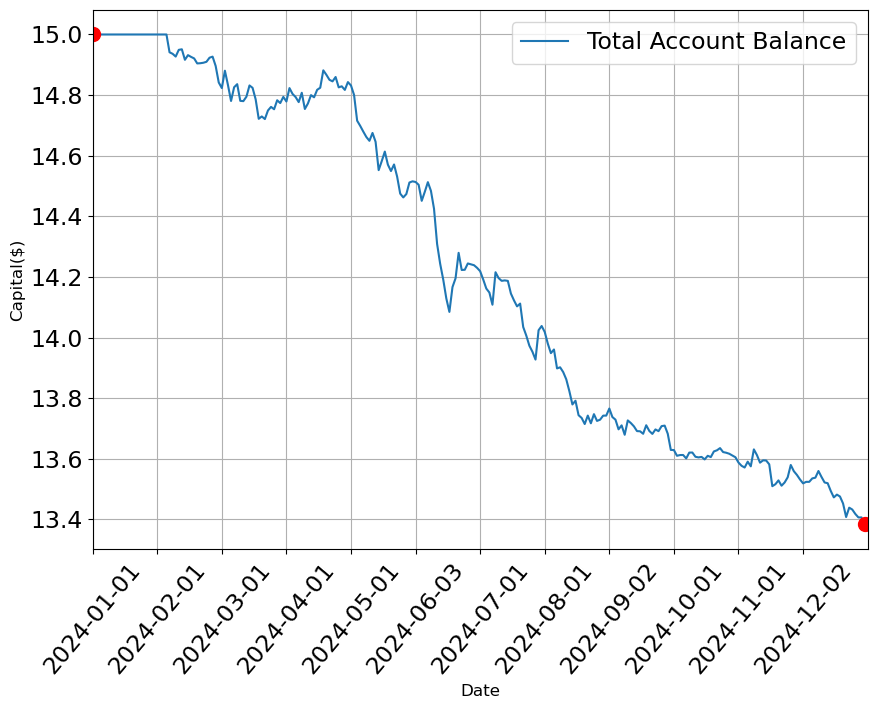

In [34]:
results, pairs_summary = summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  pairs, ticker_segment_dict,
                                                  n_years=1)

In [35]:
results

{'n_pairs': 15,
 'portfolio_sharpe_ratio': np.float64(-0.30917396218227494),
 'avg_total_roi': np.float64(-10.777359985282667),
 'avg_annual_roi': np.float64(-10.777359985282665),
 'pct_positive_trades_per_pair': np.float64(42.646697239709944),
 'pct_pairs_with_positive_results': 13.333333333333334,
 'avg_half_life': np.float64(50.666666666666664),
 'avg_hurst_exponent': np.float64(0.42059157881012094)}

In [36]:
pairs_summary

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,MTUM,iShares MSCI USA Momentum Factor ETF,XT,iShares Exponential Technologies ETF,-4.375083,0.000328,114,28,0.374344,9,6,0.272348,60.000000
1,IEFA,iShares Core MSCI EAFE ETF,PIN,Invesco India ETF,-2.703027,0.073516,73,77,0.471957,12,6,-0.041464,66.666667
2,FTXL,First Trust Nasdaq Semiconductor ETF,SOXX,iShares PHLX Semiconductor ETF,-2.867138,0.049305,97,31,0.367390,1,1,-0.243071,50.000000
3,PIN,Invesco India ETF,TLTD,FlexShares Morningstar Developed Markets ex-US...,-2.926240,0.042381,45,85,0.486149,6,7,-1.112614,46.153846
4,IXN,iShares Global Tech ETF,QQQ,Invesco QQQ Trust,-2.689835,0.075814,48,63,0.421462,2,7,-1.203894,22.222222
5,IXN,iShares Global Tech ETF,VGT,Vanguard Information Technology Index Fund ETF...,-3.262747,0.016628,64,50,0.407756,3,3,-1.390521,50.000000
6,HACK,ETFMG Prime Cyber Security ETF,IGV,iShares Expanded Tech-Software Sector ETF,-3.519986,0.007488,60,59,0.397805,12,8,-1.442218,60.000000
7,NULG,Nuveen ESG Large-Cap Growth ETF,QQQE,Direxion NASDAQ-100 Equal Weighted Index Shares,-3.281315,0.015735,113,36,0.387479,7,17,-1.467463,29.166667
8,IXN,iShares Global Tech ETF,IYW,iShares U.S. Technology ETF,-2.954438,0.039374,65,49,0.455861,7,9,-1.476994,43.750000
9,ONEQ,Fidelity Nasdaq Composite Index ETF,QQEW,First Trust NASDAQ-100 Equal Weighted Index Fund,-3.491915,0.008197,102,38,0.437543,16,26,-1.603856,38.095238


Test:

In [37]:
true_test = [summaries_rnn[i]['spread(t)'] for i in range(len(pairs))]
predictions = [summaries_rnn[i]['prediction(t)'] for i in range(len(pairs))]
_ = evaluate_forecasting(len(pairs), true_test, predictions)

95271813.07E-4
39987.44E-3
19856.84E-3
48.79%


## **Test with active pairs on validation set**

In [38]:
cumret_val = np.asarray(cumret_val)
profitable_pairs_indices = np.argwhere(cumret_val > 0)
profitable_pairs = [pairs[i] for i in profitable_pairs_indices.flatten()]
model_rnn, cumret_test, sharperatio_test, summaries_rnn, balance_summaries_rnn = \
        test_specific_model(n_in, hidden_nodes, pairs, path=current_path,
                                               low_quantile=low_quantile, high_quantile=high_quantile, lag=1, 
                                               profitable_pairs_indices=profitable_pairs_indices)
performance_rnn = [(summaries_rnn[i], balance_summaries_rnn[i]) for i in range(len(profitable_pairs))]
performance_rnn


Pair loaded: HACK_IGV:
Check pairs: HACK_IGV.
Accumulated return: -4.71%
Sharpe Ratio: -1.4422176883173508

Pair loaded: FTEC_IXN:
Check pairs: FTEC_IXN.
Accumulated return: -21.23%
Sharpe Ratio: -2.6593384634962844

Pair loaded: IEFA_PIN:
Check pairs: IEFA_PIN.
Accumulated return: 4.65%
Sharpe Ratio: -0.0414641702810511

Pair loaded: FTXL_SOXX:
Check pairs: FTXL_SOXX.
Accumulated return: -0.62%
Sharpe Ratio: -0.24307144104349393


[(            prediction(t)  prediction(t+1)  spread(t)  predicted_change(%)  \
  date                                                                         
  2024-02-06      13.125279                0  13.188171             0.000000   
  2024-02-07      13.142690                0  13.837432            -0.344861   
  2024-02-08      13.360344                0  14.084449            -3.447809   
  2024-02-09      13.590336                0  15.256656            -3.508216   
  2024-02-12      14.114417                0  15.266879            -7.486821   
  ...                   ...              ...        ...                  ...   
  2024-12-24      15.151015                0  15.065428            -0.176119   
  2024-12-26      15.202695                0  15.679944             0.911138   
  2024-12-27      15.422525                0  15.822819            -1.641704   
  2024-12-30      15.621718                0  15.643245            -1.270954   
  2024-12-31      15.698210             

Annual ROI:  -5.475198478962895
25.0 % of the pairs had positive returns
Sharpe Ratio assumming IID returns:  -1.4836545249042141
Autocorrelation:  -0.0934328364565328
Daily Sharpe Ratio -0.09142480693196876
Total number of trades:  48
Positive trades:  27
Negative trades:  21
Total Drawdown Days: 120 days
Max DD period: 2 days
Max DD period: 241 days
Maximum drawdown of portfolio: -10.51%


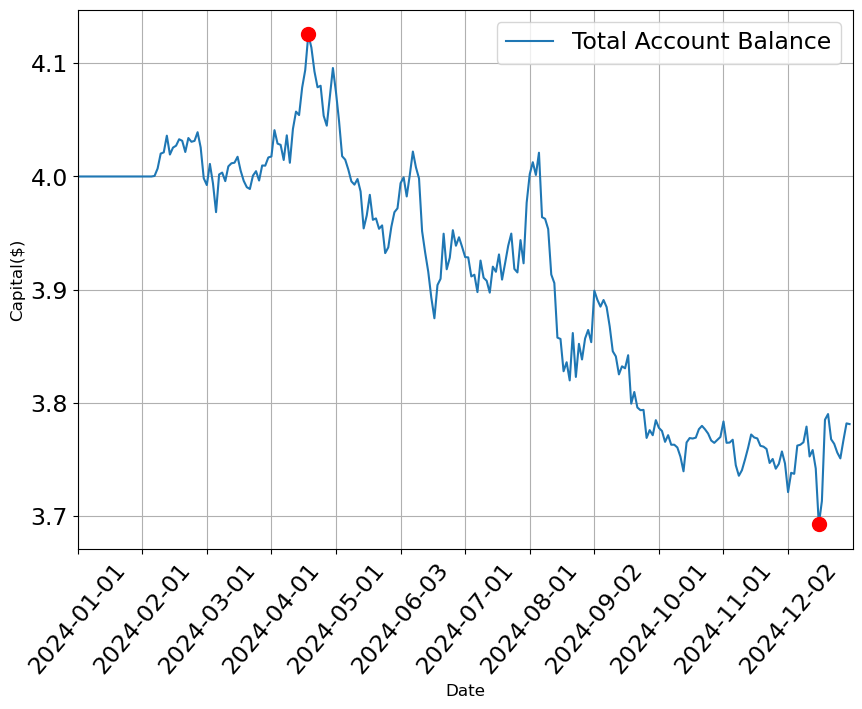

In [39]:
results, pairs_summary = summarize_results(sharperatio_test,
                                                  cumret_test,
                                                  performance_rnn,
                                                  profitable_pairs, ticker_segment_dict,
                                                  n_years=1)

In [40]:
results

{'n_pairs': 4,
 'portfolio_sharpe_ratio': np.float64(-0.09142480693196876),
 'avg_total_roi': np.float64(-5.475198478962893),
 'avg_annual_roi': np.float64(-5.475198478962895),
 'pct_positive_trades_per_pair': np.float64(50.416666666666664),
 'pct_pairs_with_positive_results': 25.0,
 'avg_half_life': np.float64(51.0),
 'avg_hurst_exponent': np.float64(0.4038738685959524)}

In [41]:
pairs_summary

,Leg1,Leg1_Segmt,Leg2,Leg2_Segmt,t_statistic,p_value,zero_cross,half_life,hurst_exponent,positive_trades,negative_trades,sharpe_result,positive_trades_per_pair_pct
0,IEFA,iShares Core MSCI EAFE ETF,PIN,Invesco India ETF,-2.703027,0.073516,73,77,0.471957,12,6,-0.041464,66.666667
1,FTXL,First Trust Nasdaq Semiconductor ETF,SOXX,iShares PHLX Semiconductor ETF,-2.867138,0.049305,97,31,0.367390,1,1,-0.243071,50.000000
2,HACK,ETFMG Prime Cyber Security ETF,IGV,iShares Expanded Tech-Software Sector ETF,-3.519986,0.007488,60,59,0.397805,12,8,-1.442218,60.000000
3,FTEC,Fidelity MSCI Information Technology Index ETF,IXN,iShares Global Tech ETF,-3.601253,0.005737,94,37,0.378343,2,6,-2.659338,25.000000
